# **Análisis estratégico de ventas y comportamiento del consumidor: sector automoción**

## Resumen del Proyecto
Este proyecto consiste en un análisis integral de un conjunto de datos de ventas de una compañía del sector del automóvil, evolucionando desde un EDA exhaustivo hasta la implementación de modelos de segmentación y contraste estadístico. El objetivo es transformar datos transaccionales en insights accionables que permitan optimizar la toma de decisiones, entender el ciclo de vida del cliente y evaluar con rigor científico el rendimiento de las líneas de productos. (Unidad monetaria: €).

## Objetivos principales

- Identificación de Patrones de Consumo y Adquisición: Analizar el comportamiento histórico de las ventas y la tasa de captación de nuevos clientes para determinar los factores que impulsan la demanda y la expansión del mercado.

- Optimización del Portafolio de Productos: Evaluar el rendimiento de las distintas líneas de negocio para identificar productos estrella, categorías con bajo rendimiento y oportunidades de venta cruzada.

- Análisis de la Salud Operativa y Logística: Examinar el ciclo de vida de los pedidos y su estado de cumplimiento para detectar posibles cuellos de botella en la cadena de suministro o áreas de fricción en la entrega.

- Segmentación y Valor del Cliente: Clasificar la cartera de clientes en función de la recencia, frecuencia y volumen de compra, permitiendo diseñar estrategias de retención más efectivas.

- Inteligencia de Negocio para la Toma de Decisiones: Transformar datos transaccionales complejos en visualizaciones claras que faciliten la planificación financiera y la proyección de ventas a futuro.

## Librerías

In [99]:
# Importamos las librerías necesarias

# Manipulación de datos
import pandas as pd
import numpy as np  

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Nulos
import missingno as msno

# Otras librerías
import os
import warnings
warnings.filterwarnings('ignore')
import sidetable
# comfiguramos para mostrar todas las columnas del dataframe
pd.set_option('display.max_columns', None)

# Análisis de datos
from scipy import stats
import pingouin as pg

## Carga de datos

In [21]:
# Creamos el path del dataset
path = r"C:\Users\angel\Desktop\Data analyst\práctica_python\proyectos\venta_coches"

In [22]:
# Creamos la lista de todos los archivos
lista = os.listdir(path)

In [23]:
# Creamos la lista de los archivos csv o xlsx
files = [file for file in lista if file.endswith('.csv') or file.endswith('.xlsx')]

In [24]:
# Creamos un diccionario vacío para almacenar los dataframes y un for para leer cada archivo y almacenarlo en el diccionario
dicc_df = {}
for file in files:
    ruta = os.path.join(path, file)
    if file.endswith('.csv'):
        df = pd.read_csv(ruta)
    else:
        df = pd.read_excel(ruta)
    dicc_df[file] = df
    print("Archivo '{}' leído correctamente.".format(file))

Archivo 'Auto Sales data.csv' leído correctamente.
Archivo 'Auto Sales data_limpio.csv' leído correctamente.


## Exploración inical del dataset

In [25]:
# Guardamos en una variable el dataset
df: pd.DataFrame = dicc_df["Auto Sales data.csv"]

In [26]:
# Vemos las primeras filas del dataset
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,24/02/2018,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,07/05/2018,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,01/07/2018,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,25/08/2018,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,10168,36,96.66,1,3479.76,28/10/2018,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,6505556809,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium


In [27]:
# Vemos las últimas filas del dataset
df.tail()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
2742,10350,20,112.22,15,2244.40,02/12/2019,2924,Shipped,Ships,54,S72_3212,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",Madrid,28034,Spain,Freyre,Diego,Small
2743,10373,29,137.19,1,3978.51,31/01/2020,2865,Shipped,Ships,54,S72_3212,"Oulu Toy Supplies, Inc.",981-443655,Torikatu 38,Oulu,90110,Finland,Koskitalo,Pirkko,Medium
2744,10386,43,125.99,4,5417.57,01/03/2020,2836,Resolved,Ships,54,S72_3212,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",Madrid,28034,Spain,Freyre,Diego,Medium
2745,10397,34,62.24,1,2116.16,28/03/2020,2810,Shipped,Ships,54,S72_3212,Alpha Cognac,61.77.6555,1 rue Alsace-Lorraine,Toulouse,31000,France,Roulet,Annette,Small
2746,10414,47,65.52,9,3079.44,06/05/2020,2772,On Hold,Ships,54,S72_3212,Gifts4AllAges.com,6175559555,8616 Spinnaker Dr.,Boston,51003,USA,Yoshido,Juri,Medium


In [28]:
# Vemos 3 filas aleatorias del dataset
df.sample(3)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
2147,10355,38,39.83,10,1513.54,07/12/2019,2324,Shipped,Motorcycles,40,S32_2206,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",Madrid,28034,Spain,Freyre,Diego,Small
1960,10110,48,34.47,5,1654.56,18/03/2018,2766,Shipped,Vintage Cars,41,S24_3969,"AV Stores, Co.",(171) 555-1555,Fauntleroy Circus,Manchester,EC2 5NT,UK,Ashworth,Victoria,Small
176,10127,46,245.20,2,11279.20,03/06/2018,905,Shipped,Classic Cars,207,S12_1108,Muscle Machine Inc,2125557413,4092 Furth Circle,NYC,10022,USA,Young,Jeff,Large


In [29]:
# Vemos las filas y las columnas del dataset
filas, columnas = df.shape
print("El dataset tiene {} filas y {} columnas.".format(filas, columnas))

El dataset tiene 2747 filas y 20 columnas.


In [30]:
# Vemos las columnas del dataset
columnas = df.columns
columnas

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'DAYS_SINCE_LASTORDER', 'STATUS', 'PRODUCTLINE',
       'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'CITY',
       'POSTALCODE', 'COUNTRY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='object')

In [31]:
# Vemos el tipo de datos de cada columna
df.dtypes

ORDERNUMBER               int64
QUANTITYORDERED           int64
PRICEEACH               float64
ORDERLINENUMBER           int64
SALES                   float64
ORDERDATE                object
DAYS_SINCE_LASTORDER      int64
STATUS                   object
PRODUCTLINE              object
MSRP                      int64
PRODUCTCODE              object
CUSTOMERNAME             object
PHONE                    object
ADDRESSLINE1             object
CITY                     object
POSTALCODE               object
COUNTRY                  object
CONTACTLASTNAME          object
CONTACTFIRSTNAME         object
DEALSIZE                 object
dtype: object

In [32]:
# Vemos información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2747 entries, 0 to 2746
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ORDERNUMBER           2747 non-null   int64  
 1   QUANTITYORDERED       2747 non-null   int64  
 2   PRICEEACH             2747 non-null   float64
 3   ORDERLINENUMBER       2747 non-null   int64  
 4   SALES                 2747 non-null   float64
 5   ORDERDATE             2747 non-null   object 
 6   DAYS_SINCE_LASTORDER  2747 non-null   int64  
 7   STATUS                2747 non-null   object 
 8   PRODUCTLINE           2747 non-null   object 
 9   MSRP                  2747 non-null   int64  
 10  PRODUCTCODE           2747 non-null   object 
 11  CUSTOMERNAME          2747 non-null   object 
 12  PHONE                 2747 non-null   object 
 13  ADDRESSLINE1          2747 non-null   object 
 14  CITY                  2747 non-null   object 
 15  POSTALCODE           

In [33]:
# Vemos el numero de tipo de datos de cada columna
df.dtypes.value_counts()

object     13
int64       5
float64     2
Name: count, dtype: int64

In [34]:
# Vemos los principales estadísticos de las variables numéricas del dataset
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
ORDERNUMBER,2747.0,10259.761558,91.877521,10100.00,10181.000,10264.00,10334.500,10425.00
QUANTITYORDERED,2747.0,35.103021,9.762135,6.00,27.000,35.00,43.000,97.00
PRICEEACH,2747.0,101.098952,42.042549,26.88,68.745,95.55,127.100,252.87
ORDERLINENUMBER,2747.0,6.491081,4.230544,1.00,3.000,6.00,9.000,18.00
SALES,2747.0,3553.047583,1838.953901,482.13,2204.350,3184.80,4503.095,14082.80
DAYS_SINCE_LASTORDER,2747.0,1757.085912,819.280576,42.00,1077.000,1761.00,2436.500,3562.00
MSRP,2747.0,100.691664,40.114802,33.00,68.000,99.00,124.000,214.00


In [35]:
# Vemos los principales estadísticos de las variables categóricas del dataset
df.describe(include="object").T

,count,unique,top,freq
ORDERDATE,2747,246,14/11/2018,38
STATUS,2747,6,Shipped,2541
PRODUCTLINE,2747,7,Classic Cars,949
PRODUCTCODE,2747,109,S18_3232,51
CUSTOMERNAME,2747,89,Euro Shopping Channel,259
PHONE,2747,88,(91) 555 94 44,259
ADDRESSLINE1,2747,89,"C/ Moralzarzal, 86",259
CITY,2747,71,Madrid,304
POSTALCODE,2747,73,28034,259
COUNTRY,2747,19,USA,928


In [36]:
# Vemos las columnas categóricas del dataset

columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()
columnas_categoricas

['ORDERDATE',
 'STATUS',
 'PRODUCTLINE',
 'PRODUCTCODE',
 'CUSTOMERNAME',
 'PHONE',
 'ADDRESSLINE1',
 'CITY',
 'POSTALCODE',
 'COUNTRY',
 'CONTACTLASTNAME',
 'CONTACTFIRSTNAME',
 'DEALSIZE']

In [37]:
# Vemos los valores únicos de cada columna y el número de valores únicos. Se descartan identificadores únicos (Phone, Address, Contact) y 
# fechas (que se tratarán como datetime) para priorizar variables que permitan segmentación geográfica, operativa y de volumen de negocio.
columnas_categoricas = [
 'STATUS',
 'PRODUCTLINE',
 'CITY',
 'COUNTRY',
 'CUSTOMERNAME',
 'DEALSIZE']

for columna in columnas_categoricas:
    print("Valores únicos de la columna '{}':".format(columna))
    print("Número de valores únicos:", df[columna].nunique())
    print(df[columna].unique())
    print()

Valores únicos de la columna 'STATUS':
Número de valores únicos: 6
['Shipped' 'Disputed' 'In Process' 'Cancelled' 'On Hold' 'Resolved']

Valores únicos de la columna 'PRODUCTLINE':
Número de valores únicos: 7
['Motorcycles' 'Classic Cars' 'Trucks and Buses' 'Vintage Cars' 'Planes'
 'Ships' 'Trains']

Valores únicos de la columna 'CITY':
Número de valores únicos: 71
['NYC' 'Reims' 'Paris' 'Pasadena' 'Burlingame' 'Lille' 'Bergen'
 'Melbourne' 'Newark' 'Bridgewater' 'Nantes' 'Cambridge' 'Helsinki'
 'Stavern' 'Allentown' 'Salzburg' 'Chatswood' 'New Bedford' 'Liverpool'
 'Madrid' 'Lule' 'Singapore' 'South Brisbane' 'Philadelphia' 'Lyon'
 'Vancouver' 'Burbank' 'New Haven' 'Minato-ku' 'Torino' 'Boras'
 'Versailles' 'San Rafael' 'Nashua' 'Brickhaven' 'North Sydney' 'Montreal'
 'Osaka' 'White Plains' 'Kobenhavn' 'London' 'Toulouse' 'Barcelona'
 'San Diego' 'Bruxelles' 'Tsawassen' 'Boston' 'Cowes' 'Oulu' 'San Jose'
 'Graz' 'Makati City' 'Marseille' 'Koln' 'Gensve' 'Reggio Emilia'
 'Frankfurt' 'E

In [38]:
# Vemos el número de valores únicos de la columna "ORDERNUMBER", es decir, el número de pedidos únicos que hay en el dataset.
df["ORDERNUMBER"].nunique()

298

In [39]:
# Vemos los valores nulos del dataset
df.isnull().sum()

ORDERNUMBER             0
QUANTITYORDERED         0
PRICEEACH               0
ORDERLINENUMBER         0
SALES                   0
ORDERDATE               0
DAYS_SINCE_LASTORDER    0
STATUS                  0
PRODUCTLINE             0
MSRP                    0
PRODUCTCODE             0
CUSTOMERNAME            0
PHONE                   0
ADDRESSLINE1            0
CITY                    0
POSTALCODE              0
COUNTRY                 0
CONTACTLASTNAME         0
CONTACTFIRSTNAME        0
DEALSIZE                0
dtype: int64

In [40]:
# Vemos los valores duplicados del dataset
df.duplicated().sum()

np.int64(0)

**Calidad y estructura del dataset**
- Composición del Dataset: Trabajé con un volumen de 2.747 registros, combinando variables categóricas y numéricas que recogen todo el ciclo de la transacción: desde detalles del producto y precios sugeridos (MSRP) hasta información estratégica del cliente.

- Integridad Total: Tras una fase de inspección, confirmé que el dataset contaba con un 100% de valores informados (sin nulos) y una ausencia total de registros duplicados, lo que garantiza una base de trabajo limpia y consistente.

- Refinamiento de Variables: Llevé a cabo un tratamiento de tipos de datos para asegurar que cada métrica (especialmente las transaccionales y de fechas) estuviera correctamente optimizada para el posterior análisis estadístico.


**Insights del análisis exploratorio inicial**
- Desempeño Financiero y Precios
    - Valor de Ticket: El importe medio por pedido es de 3.553€. Existe una gran amplitud en las ventas, con transacciones que van desde los 482€ hasta picos de 14.082€.
    - Estrategia de Precios: El precio promedio por artículo (101€) está ligeramente por encima del MSRP sugerido (100€), lo que indica un excelente posicionamiento de marca y poca dependencia de descuentos agresivos para cerrar ventas.

- Dinámica de Pedidos
    - Volumen por transacción: Los clientes suelen comprar una media de 35 artículos por pedido. La mayoría de las operaciones se clasifican como "Tamaño Medio".
    - Pico Histórico: El 14/11/2018 se registró la mayor actividad operativa con 38 pedidos en una sola jornada. 

- Segmentación de Mercado
    - Producto Estrella: La línea de Coches Clásicos es, con diferencia, la más popular con 949 pedidos, consolidándose como el núcleo del negocio.
    - Geografía: País dominante: EE.UU. (928 pedidos).
    - Ciudad referente: Madrid destaca como la ciudad con mayor número de transacciones (304 pedidos).

## Limpieza y tratamiento de los datos

In [41]:
# Cambiamos el nombre de las columnas a minúsculas
df.columns = df.columns.str.lower()
df.columns

Index(['ordernumber', 'quantityordered', 'priceeach', 'orderlinenumber',
       'sales', 'orderdate', 'days_since_lastorder', 'status', 'productline',
       'msrp', 'productcode', 'customername', 'phone', 'addressline1', 'city',
       'postalcode', 'country', 'contactlastname', 'contactfirstname',
       'dealsize'],
      dtype='object')

In [42]:
# Añadimos _ al nombre de las columnas para mejorar la legibilidad
df.columns.to_list()

['ordernumber',
 'quantityordered',
 'priceeach',
 'orderlinenumber',
 'sales',
 'orderdate',
 'days_since_lastorder',
 'status',
 'productline',
 'msrp',
 'productcode',
 'customername',
 'phone',
 'addressline1',
 'city',
 'postalcode',
 'country',
 'contactlastname',
 'contactfirstname',
 'dealsize']

In [43]:
# creamos una lista con el nuevo nombre de las columnas
nuevo_nombre_columnas = ['order_number',
 'quantity_ordered',
 'price_each',
 'order_line_number',
 'sales',
 'order_date',
 'days_since_last_order',
 'status',
 'product_line',
 'msrp',
 'product_code',
 'customer_name',
 'phone',
 'address_line1',
 'city',
 'postal_code',
 'country',
 'contact_last_name',
 'contact_first_name',
 'deal_size']

In [44]:
# Igualamos el nuevo nombre de las columnas al dataframe
df.columns = nuevo_nombre_columnas

In [45]:
# Cambiamos el tipo de dato de la columna "order_date" a datetime
df['order_date'] = pd.to_datetime(df['order_date'])

In [46]:
# Eliminamos la columna "days_since_last_order" para crear una nueva pero que vaya desde la fecha de la última compra hasta la fecha de hoy.
df.drop('days_since_last_order', axis=1, inplace=True)

In [47]:
# Creamos la columna "days_since_last_order" que va desde la fecha de la última compra hasta la fecha de hoy.
df["days_since_last_order"] = (pd.Timestamp.now() - df['order_date']).dt.days

In [48]:
# Vemos el df con los cambios realizados
df.head(2)

,order_number,quantity_ordered,price_each,order_line_number,sales,order_date,status,product_line,msrp,product_code,customer_name,phone,address_line1,city,postal_code,country,contact_last_name,contact_first_name,deal_size,days_since_last_order
0,10107,30,95.70,2,2871.0,2018-02-24,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small,2967
1,10121,34,81.35,5,2765.9,2018-05-07,Shipped,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small,2895


In [49]:
# Guardamos el df limpio en un nuevo csv
#df.to_csv(r"C:\Users\angel\Desktop\Data analyst\práctica_python\proyectos\venta_coches\coches_limpio.csv", index=False)

## EDA

### Análisis univariante

Variables categóricas

Gráfico de barras de la variable 'status':


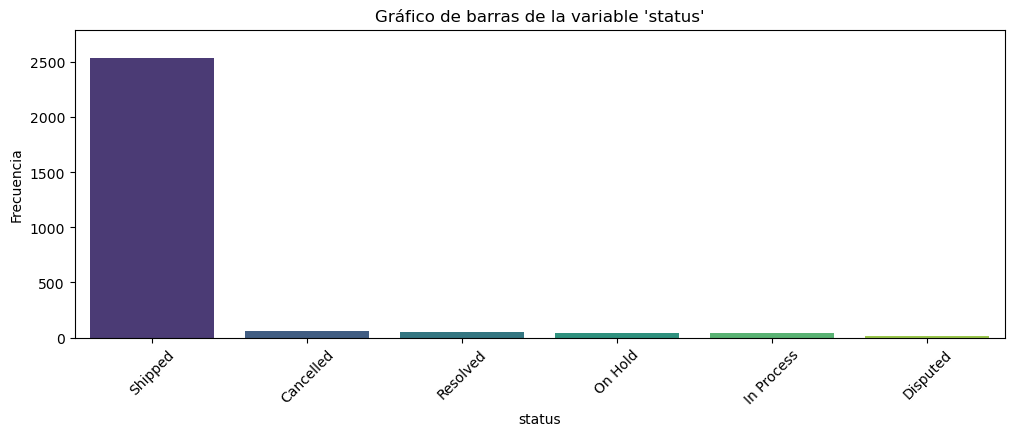

,status,count,percent,cumulative_count,cumulative_percent
0,Shipped,2541,92.500910,2541,92.500910
1,Cancelled,60,2.184201,2601,94.685111
2,Resolved,47,1.710957,2648,96.396068
3,On Hold,44,1.601747,2692,97.997816
4,In Process,41,1.492537,2733,99.490353
5,Disputed,14,0.509647,2747,100.000000


****************************************************************************************************
Gráfico de barras de la variable 'product_line':


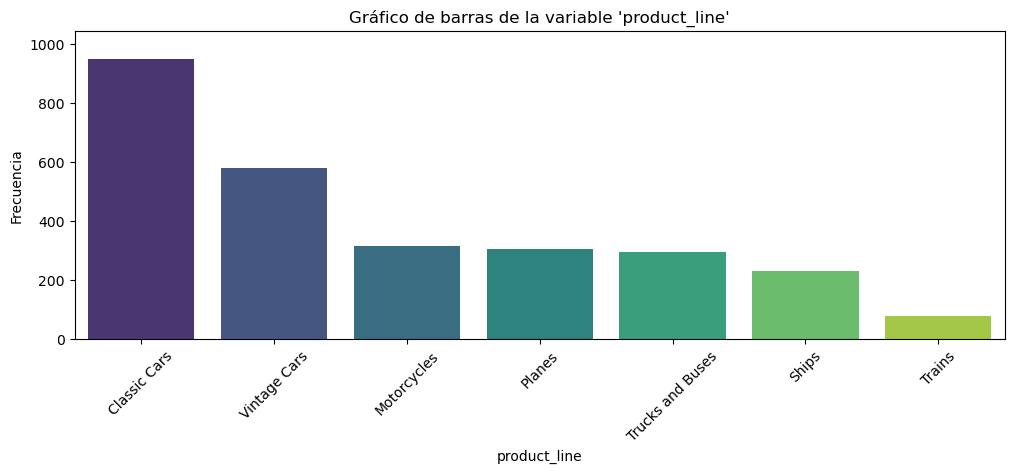

,product_line,count,percent,cumulative_count,cumulative_percent
0,Classic Cars,949,34.546778,949,34.546778
1,Vintage Cars,579,21.077539,1528,55.624317
2,Motorcycles,313,11.394248,1841,67.018566
3,Planes,304,11.066618,2145,78.085184
4,Trucks and Buses,295,10.738988,2440,88.824172
5,Ships,230,8.372770,2670,97.196942
6,Trains,77,2.803058,2747,100.000000


****************************************************************************************************
Gráfico de barras de la variable 'deal_size':


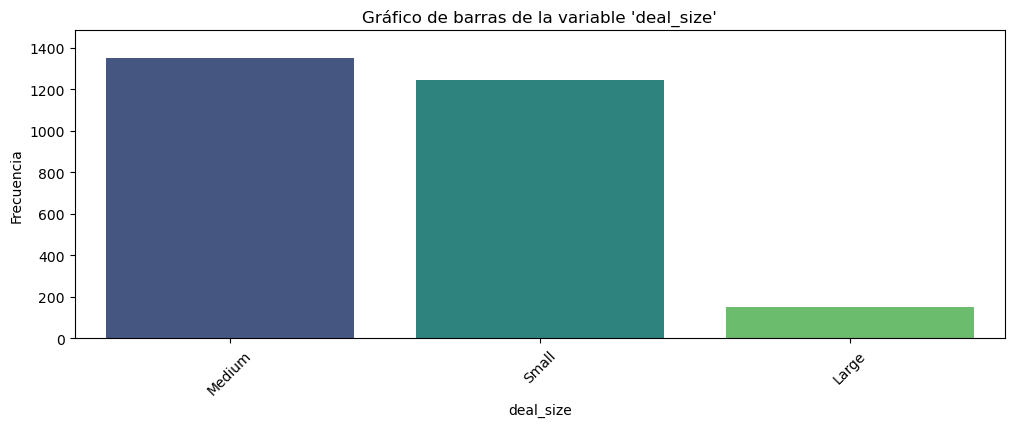

,deal_size,count,percent,cumulative_count,cumulative_percent
0,Medium,1349,49.108118,1349,49.108118
1,Small,1246,45.358573,2595,94.466691
2,Large,152,5.533309,2747,100.000000


****************************************************************************************************


In [50]:
# Graficamos un gráfico de barras y un gráfico de pastel para cada una de las columnas categóricas del dataset para ver la distribución de cada una de ellas. Utilizamos plotly para los gráficos de barras y matplotlib para los gráficos de pastel.
columnas_categoricas = [
 'status',
 'product_line',
 'deal_size']

for columna in columnas_categoricas:
    print("Gráfico de barras de la variable '{}':".format(columna))

    # Gráfico de barras con seaborn
    plt.figure(figsize=(12, 4))
    sns.countplot(data=df, x=columna, order=df[columna].value_counts().index, palette="viridis")
    plt.title("Gráfico de barras de la variable '{}'".format(columna))
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45) 
    plt.margins(y=0.1)  
    plt.show()
    display(df.stb.freq([columna]))
    print("*" * 100)

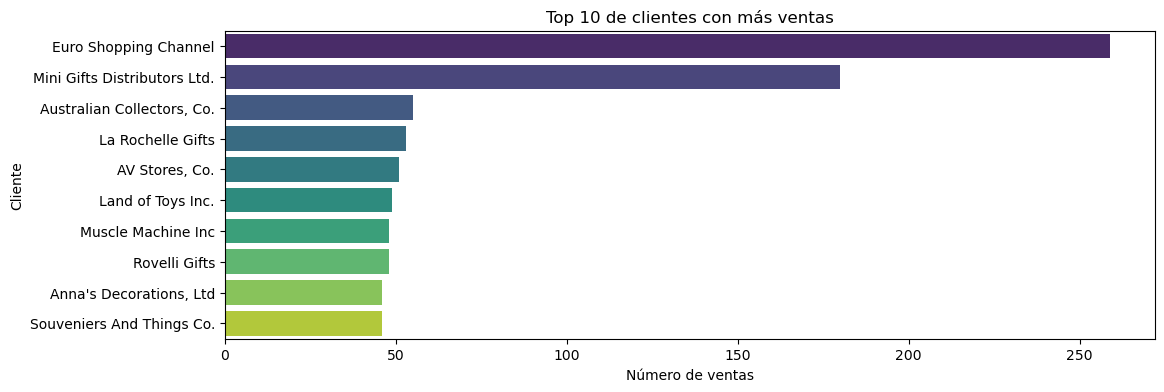

,customer_name,count,percent,cumulative_count,cumulative_percent
0,Euro Shopping Channel,259,9.428467,259,9.428467
1,Mini Gifts Distributors Ltd.,180,6.552603,439,15.981070
2,"Australian Collectors, Co.",55,2.002184,494,17.983254
3,La Rochelle Gifts,53,1.929378,547,19.912632
4,"AV Stores, Co.",51,1.856571,598,21.769203
5,Land of Toys Inc.,49,1.783764,647,23.552967
6,Rovelli Gifts,48,1.747361,695,25.300328
7,Muscle Machine Inc,48,1.747361,743,27.047688
8,Souveniers And Things Co.,46,1.674554,789,28.722242
9,"Anna's Decorations, Ltd",46,1.674554,835,30.396797


In [51]:
# Vemos el top 10 clientes con más ventas
top_clientes = df.groupby("customer_name").size().sort_values(ascending=False).reset_index(name='ventas').head(10)
plt.figure(figsize=(12, 4))
sns.barplot(data=top_clientes, x="ventas", y="customer_name", palette="viridis")
plt.title("Top 10 de clientes con más ventas")
plt.xlabel("Número de ventas")
plt.ylabel("Cliente")
plt.show()
df.stb.freq(["customer_name"]).head(10)

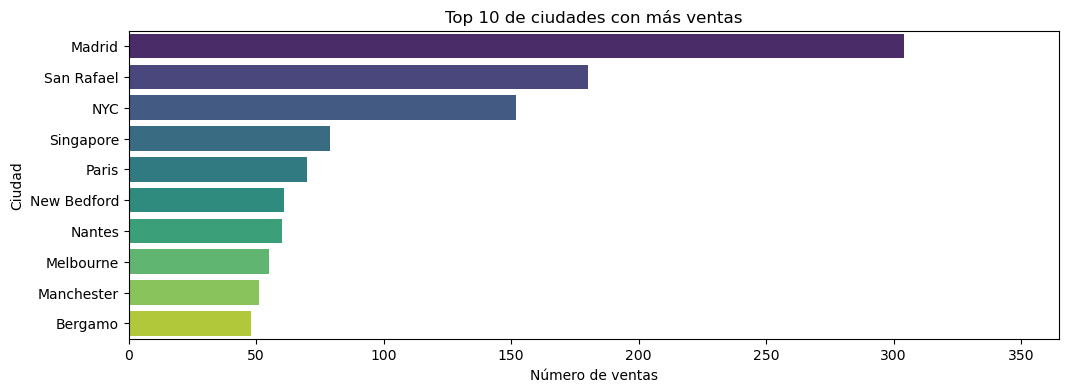

,city,count,percent,cumulative_count,cumulative_percent
0,Madrid,304,11.066618,304,11.066618
1,San Rafael,180,6.552603,484,17.619221
2,NYC,152,5.533309,636,23.152530
3,Singapore,79,2.875865,715,26.028395
4,Paris,70,2.548234,785,28.576629
5,New Bedford,61,2.220604,846,30.797233
6,Nantes,60,2.184201,906,32.981434
7,Melbourne,55,2.002184,961,34.983618
8,Manchester,51,1.856571,1012,36.840189
9,Bergamo,48,1.747361,1060,38.587550


In [52]:
# Vemos el top 10 de las ciudades con más ventas
top_ciudades = df.groupby("city").size().sort_values(ascending=False).reset_index(name='ventas').head(10)
plt.figure(figsize=(12, 4))
sns.barplot(data=top_ciudades, x="ventas", y="city", palette="viridis")
plt.title("Top 10 de ciudades con más ventas")
plt.xlabel("Número de ventas")
plt.ylabel("Ciudad")
plt.margins(x=0.2)  
plt.show()
df.stb.freq(["city"]).head(10)

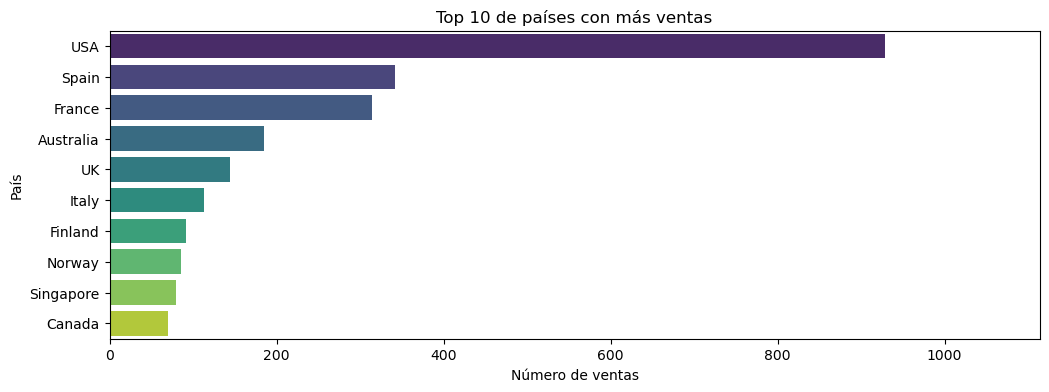

,country,count,percent,cumulative_count,cumulative_percent
0,USA,928,33.782308,928,33.782308
1,Spain,342,12.449945,1270,46.232253
2,France,314,11.430652,1584,57.662905
3,Australia,185,6.734620,1769,64.397525
4,UK,144,5.242082,1913,69.639607
5,Italy,113,4.113578,2026,73.753185
6,Finland,92,3.349108,2118,77.102293
7,Norway,85,3.094285,2203,80.196578
8,Singapore,79,2.875865,2282,83.072443
9,Canada,70,2.548234,2352,85.620677


In [53]:
# Vemos el top 10 de los países con más ventas
top_paises = df.groupby("country").size().sort_values(ascending=False).reset_index(name='ventas').head(10)
plt.figure(figsize=(12, 4))
sns.barplot(data=top_paises, x="ventas", y="country", palette="viridis")
plt.title("Top 10 de países con más ventas")
plt.xlabel("Número de ventas")
plt.ylabel("País")
plt.margins(x=0.2)
plt.show()
df.stb.freq(["country"]).head(10)

Variables numéricas

In [54]:
# Graficamos un histograma y un boxplot para cada una de las columnas numéricas del dataset para ver la distribución de cada una de ellas. Utilizamos 
# seaborn para los gráficos de histograma y boxplot.
columnas_numericas = df.select_dtypes(include="number").columns.tolist()
columnas_numericas

['order_number',
 'quantity_ordered',
 'price_each',
 'order_line_number',
 'sales',
 'msrp',
 'days_since_last_order']

In [55]:
columnas_numericas = [
 'quantity_ordered',
 'price_each',
 'sales',
 'msrp',
 'days_since_last_order']

Gráficos de la variable 'quantity_ordered':


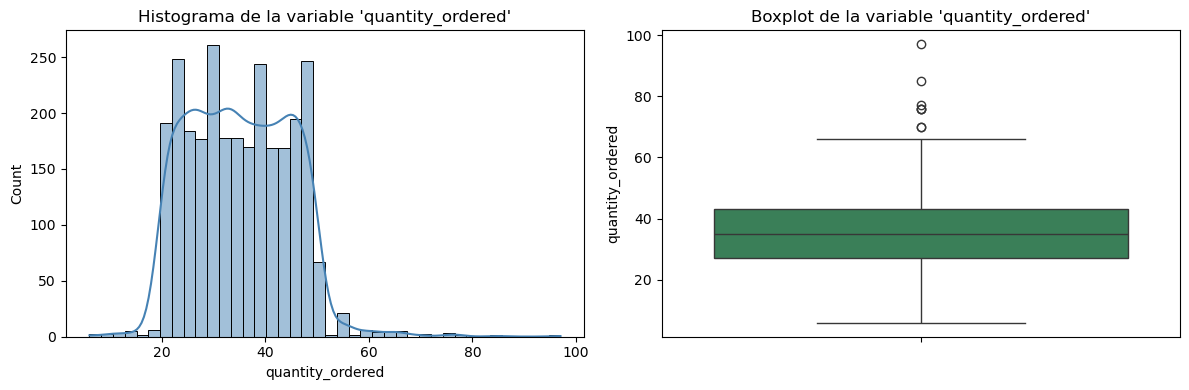

,count,mean,std,min,25%,50%,75%,max
quantity_ordered,2747.0,35.103021,9.762135,6.0,27.0,35.0,43.0,97.0


****************************************************************************************************
Gráficos de la variable 'price_each':


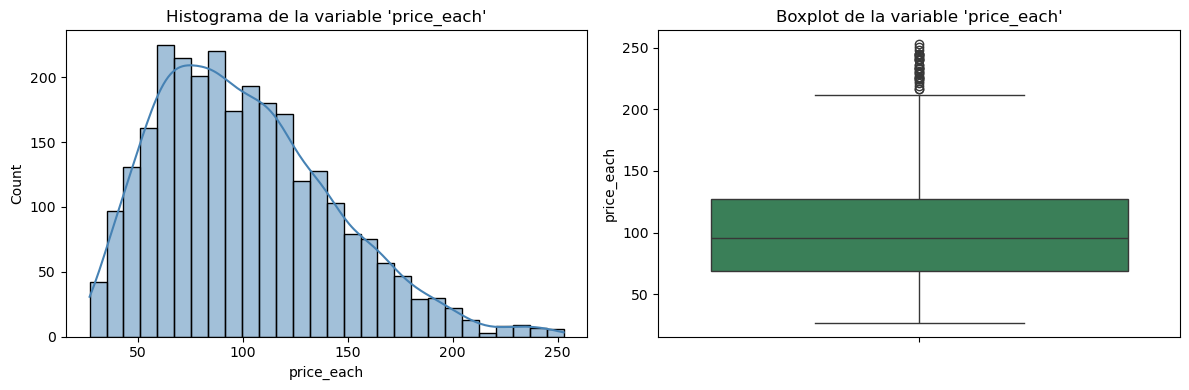

,count,mean,std,min,25%,50%,75%,max
price_each,2747.0,101.098952,42.042549,26.88,68.745,95.55,127.1,252.87


****************************************************************************************************
Gráficos de la variable 'sales':


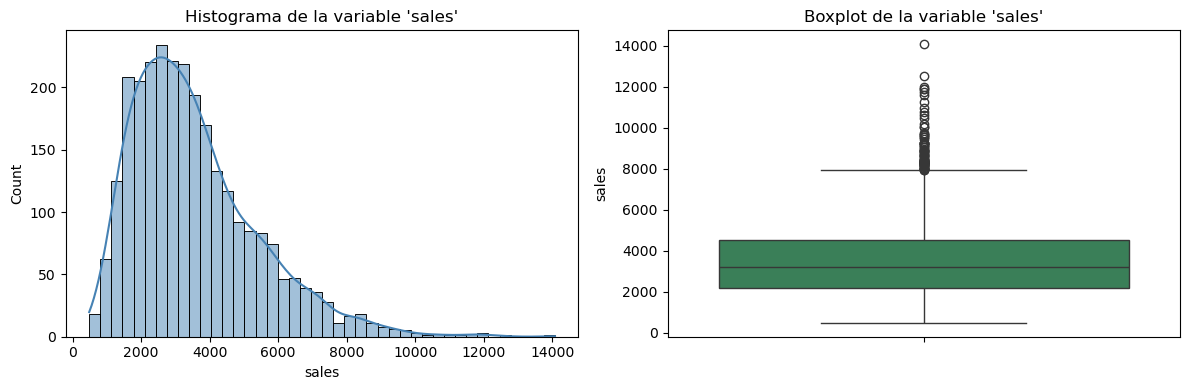

,count,mean,std,min,25%,50%,75%,max
sales,2747.0,3553.047583,1838.953901,482.13,2204.35,3184.8,4503.095,14082.8


****************************************************************************************************
Gráficos de la variable 'msrp':


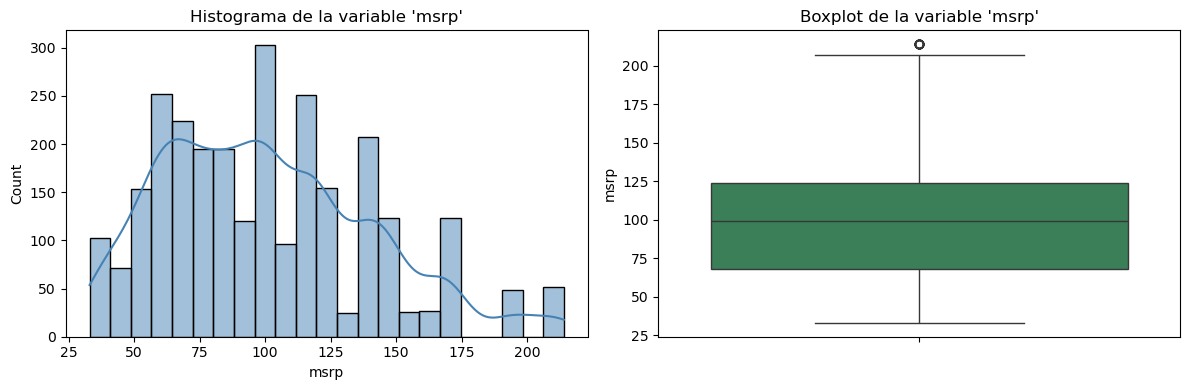

,count,mean,std,min,25%,50%,75%,max
msrp,2747.0,100.691664,40.114802,33.0,68.0,99.0,124.0,214.0


****************************************************************************************************
Gráficos de la variable 'days_since_last_order':


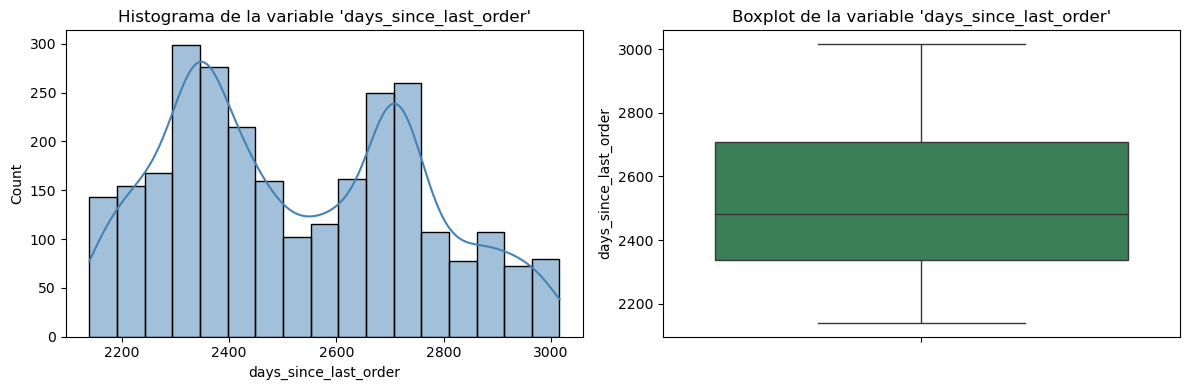

,count,mean,std,min,25%,50%,75%,max
days_since_last_order,2747.0,2523.085912,230.231295,2140.0,2336.0,2482.0,2710.0,3016.0


****************************************************************************************************


In [56]:
# Graficamos el histograma y el boxplot para cada una de las columnas numéricas del dataset
for columna in columnas_numericas:
    print("Gráficos de la variable '{}':".format(columna))
    plt.figure(figsize=(12, 4))
    
    # Gráfico de histograma con seaborn
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=columna, kde=True, color="steelblue")
    plt.title("Histograma de la variable '{}'".format(columna))
    
    # Gráfico de boxplot con seaborn
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, y=columna, color="seagreen")
    plt.title("Boxplot de la variable '{}'".format(columna))
    plt.tight_layout()
    plt.show()
    display(df[[columna]].describe().T)
    print("*" * 100)

### Análisis bivariante

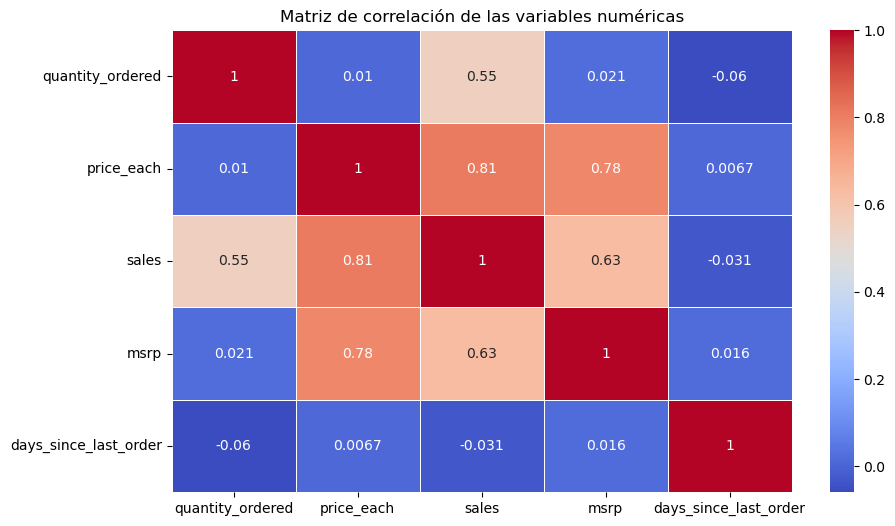

In [57]:
# Vemos la matriz de correlación de las variables numéricas del dataset utilizando un mapa de calor con seaborn.
plt.figure(figsize=(10, 6))
sns.heatmap(df[columnas_numericas].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de correlación de las variables numéricas")
plt.show()

**Insights correlación**

- Existe una correlación muy positiva entre el precio de cada pieza (precio unitario) y las ventas. La empresa genera mayores ingresos a través de productos de alto valor unitario, lo que sugiere que los clientes no son sensibles al precio.
- Existe una correlación positiva entre el precio de venta sugerido por el fabricante y las ventas. Esto refuerza refuerza que los productos que el mercado percibe como "valiosos" (los que tienen un MSRP alto) son precisamente los que mejor se venden.
- La relación entre el precio unitario y el precio de venta sugerido por el fabricante es de 0.78, es decir, es algo más barato el precio unitario que el sugerido. Esto demuestra que la empresa tiene margen para ofrecer un precio atractivo frente al oficial.
- Se observa una correlación positiva directa entre la cantidad de unidades por pedido y el volumen de ingresos . Esto confirma que el modelo de negocio escala linealmente con el volumen de unidades por transacción, sugiriendo que incentivar pedidos de mayor tamaño impacta positivamente en la facturación total.
- La correlación entre días desde el ultimo pedido y cantidad de artículos en el pedido es muy poco intensa, pero negativa (-0.06). Esto nos dice que el tamaño del pedido no depende de cuánto tiempo hace que el cliente no compra. Un cliente que compró ayer tiene la misma probabilidad de hacer un pedido grande que uno que no compra hace meses.


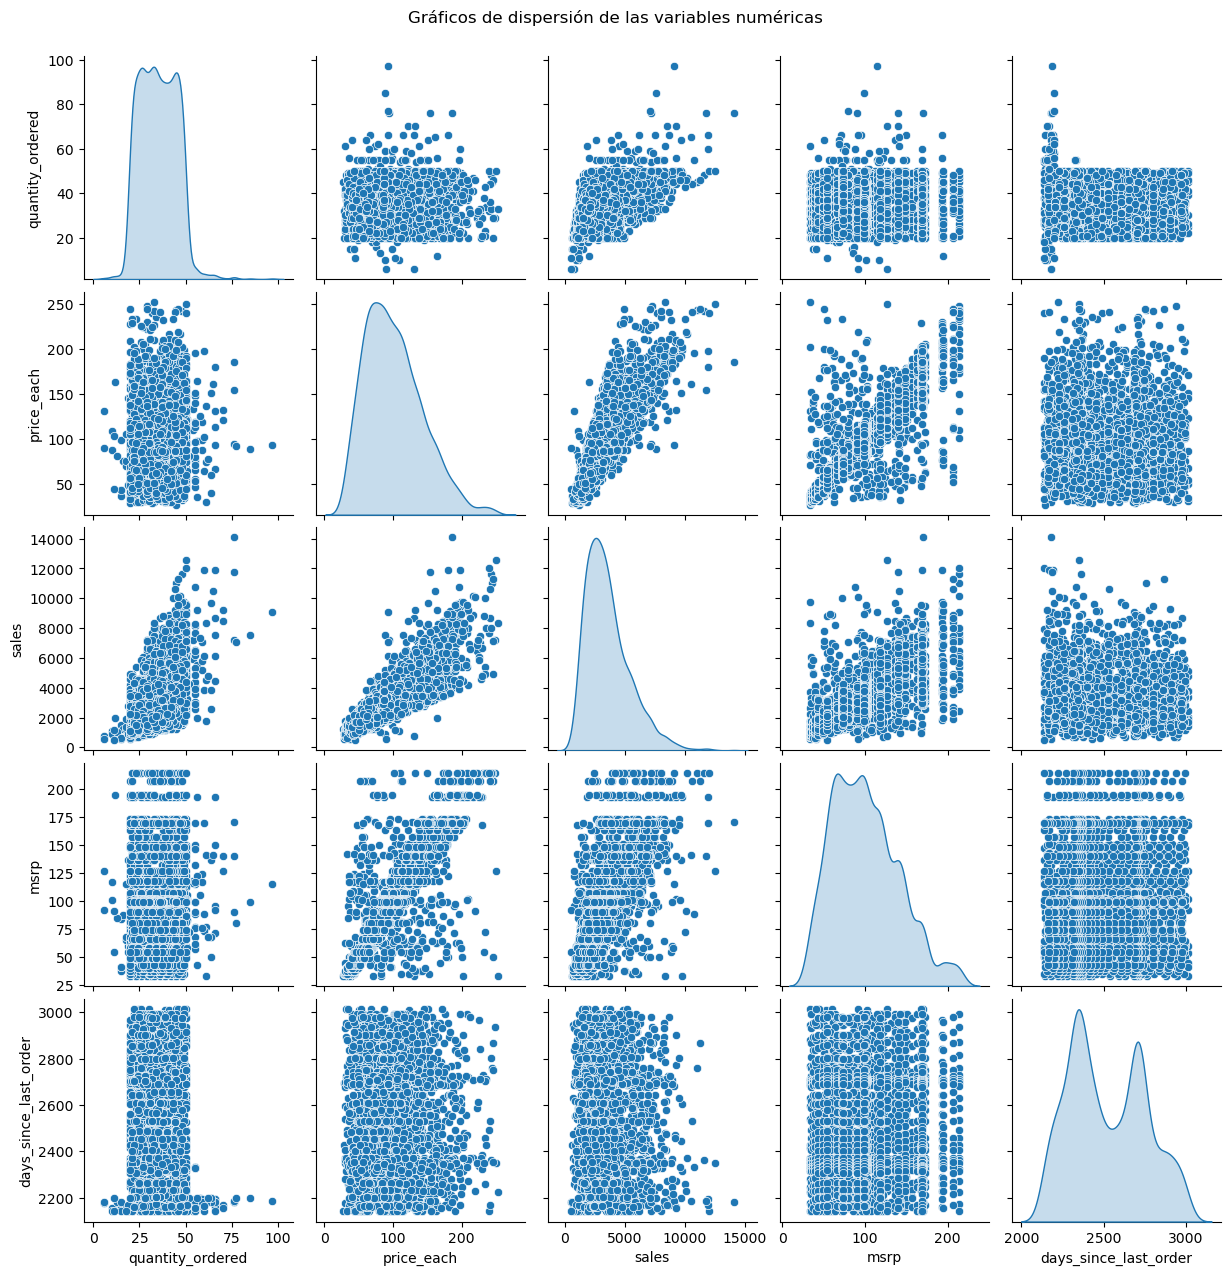

In [58]:
# Vemos la relación entre las variables numéricas del dataset utilizando gráficos de dispersión con seaborn.
sns.pairplot(df[columnas_numericas], diag_kind="kde")
plt.suptitle("Gráficos de dispersión de las variables numéricas", y=1.02)
plt.show()

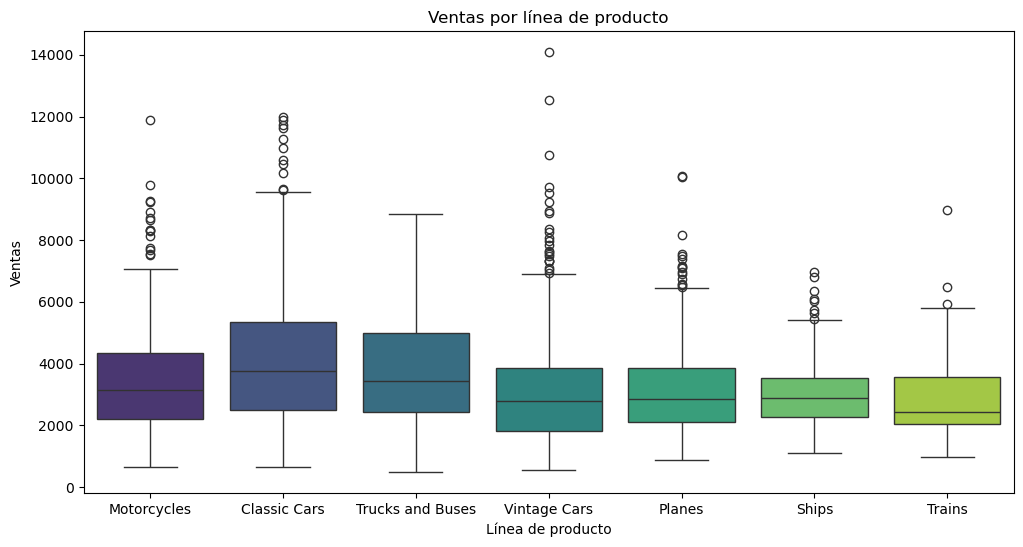

,count,mean,std,min,25%,50%,75%,max
product_line,,,,,,,,
Classic Cars,949.0,4049.387292,2051.804511,640.05,2492.880,3754.050,5331.880,12001.00
Motorcycles,313.0,3525.598051,1836.384071,651.80,2220.720,3153.600,4326.800,11886.60
Planes,304.0,3188.563882,1523.238641,875.91,2109.205,2841.805,3843.400,10066.60
Ships,230.0,3043.648783,1058.752936,1089.36,2261.295,2884.925,3531.920,6960.48
Trains,77.0,2938.226883,1456.595976,972.40,2051.560,2445.600,3564.750,8977.05
Trucks and Buses,295.0,3767.997254,1674.055922,482.13,2421.975,3451.000,4997.845,8844.12
Vintage Cars,579.0,3120.337962,1771.064556,541.14,1806.670,2795.270,3851.925,14082.80


In [59]:
# Vemos la variable "sales" en función de "product_line" para ver si hay alguna relación entre estas dos variables.
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="product_line", y="sales", palette="viridis")
plt.title("Ventas por línea de producto")
plt.xlabel("Línea de producto")
plt.ylabel("Ventas")
plt.show()
df.groupby("product_line")["sales"].describe()

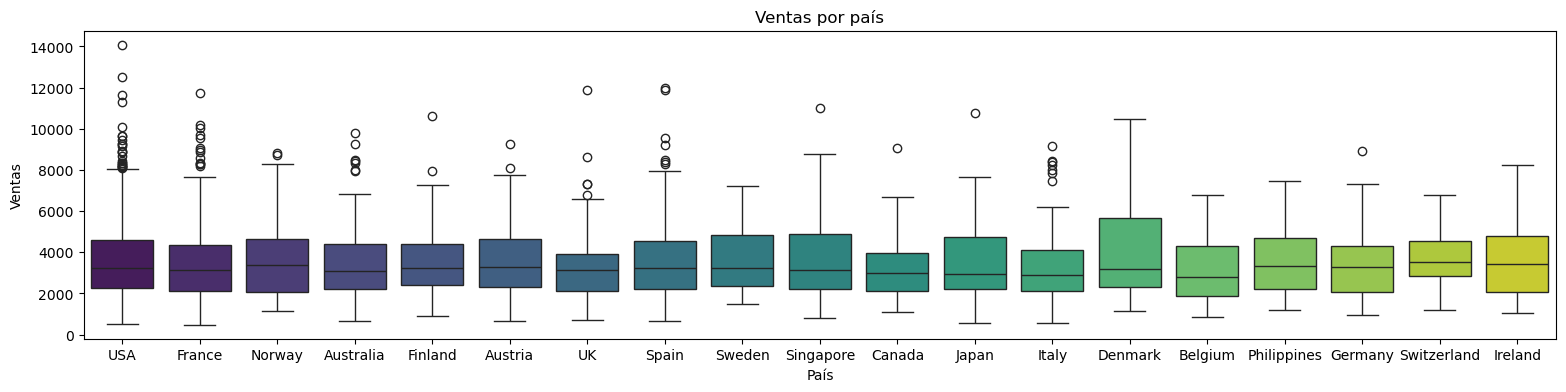

,country,count,mean,std,min,25%,50%,75%,max
16,Switzerland,31.0,3797.211613,1482.447311,1205.04,2855.4000,3540.530,4557.0400,6761.60
8,Ireland,16.0,3609.776875,2075.475123,1056.40,2066.3625,3419.965,4793.3850,8258.00
11,Norway,85.0,3617.220000,1853.403258,1129.04,2093.4400,3394.980,4660.2400,8844.12
12,Philippines,26.0,3615.989615,1613.896242,1173.15,2234.2075,3329.310,4682.2250,7483.98
1,Austria,55.0,3673.864182,1906.932800,640.05,2331.0600,3307.200,4634.7400,9240.00
7,Germany,62.0,3556.001452,1809.495392,948.99,2058.2850,3271.200,4281.8900,8940.96
15,Sweden,57.0,3684.459825,1680.831756,1467.48,2340.0000,3256.960,4850.3000,7209.11
5,Finland,92.0,3582.412065,1786.214918,891.03,2434.3950,3247.830,4381.4775,10606.20
18,USA,928.0,3615.922080,1875.659235,541.14,2257.8350,3236.060,4573.1400,14082.80
14,Spain,342.0,3554.640117,1835.823513,683.80,2221.7750,3213.805,4535.6500,12001.00


In [60]:
# Vemos la variable "sales" en función de "country" para ver si hay alguna relación entre estas dos variables.
plt.figure(figsize=(19, 4))
sns.boxplot(data=df, x="country", y="sales", palette="viridis")
plt.title("Ventas por país")
plt.xlabel("País")
plt.ylabel("Ventas")
plt.show()
display(df.groupby("country")["sales"].describe().reset_index().sort_values("50%", ascending=False))

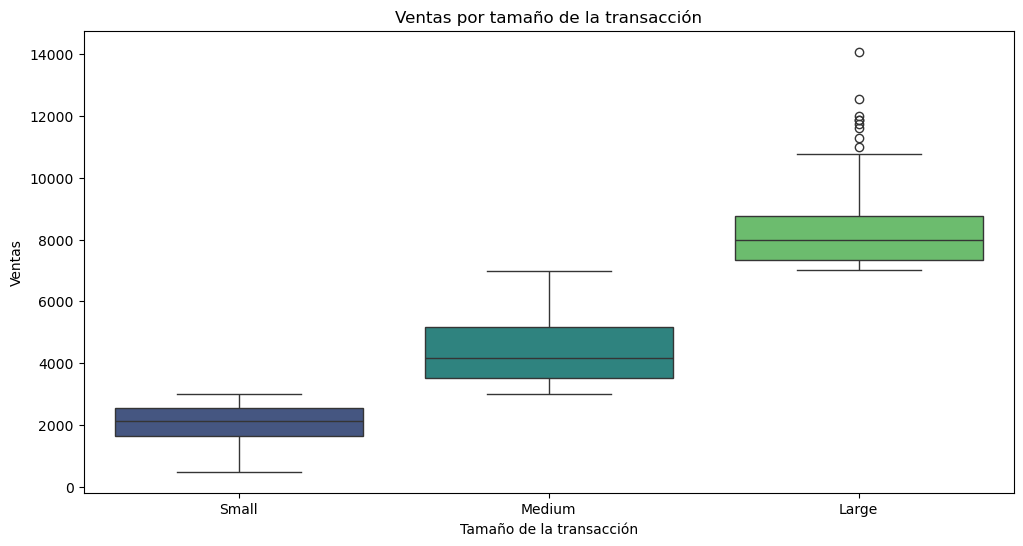

In [61]:
# Vemos la variable "sales" en función de "deal_size" utilizando un gráfico de caja con seaborn.
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="deal_size", y="sales", palette="viridis")
plt.title("Ventas por tamaño de la transacción")
plt.xlabel("Tamaño de la transacción")
plt.ylabel("Ventas")
plt.show()

### Análisis multivariante

In [62]:
# Creamos las columnas "year", "month", "semana" y "trimestre" a partir de la columna "order_date" para analizar las ventas por año, mes, semana y trimestre.
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["week"] = df["order_date"].dt.isocalendar().week
df["quarter"] = df["order_date"].dt.quarter

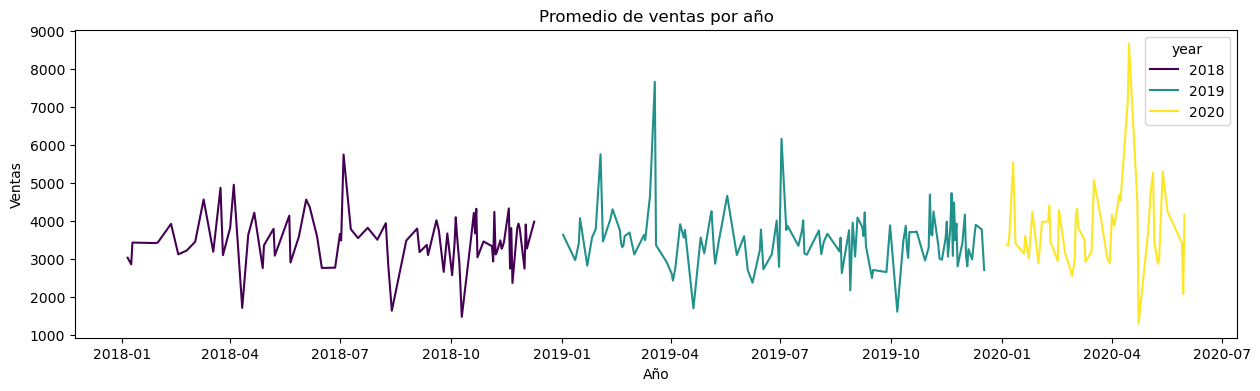

In [63]:
# Vemos el gráfico de las ventas en función del año para ver si hay alguna tendencia en las ventas a lo largo de los años.
plt.figure(figsize=(15, 4))
sns.lineplot(data=df, x="order_date", y="sales", palette="viridis", ci=None, estimator='mean', hue="year")
plt.title("Promedio de ventas por año")
plt.xlabel("Año")
plt.ylabel("Ventas")
plt.show()

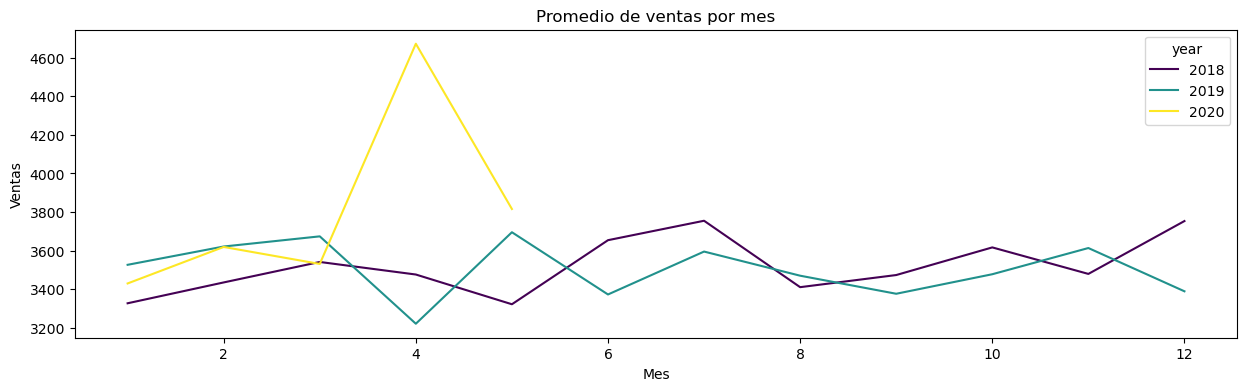

In [64]:
# Vemos el gráfico de las ventas en función del mes para ver si hay alguna tendencia en las ventas a lo largo de los años.
plt.figure(figsize=(15, 4))
sns.lineplot(data=df, x="month", y="sales", palette="viridis", ci=None, estimator='mean', hue="year")
plt.title("Promedio de ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.show()

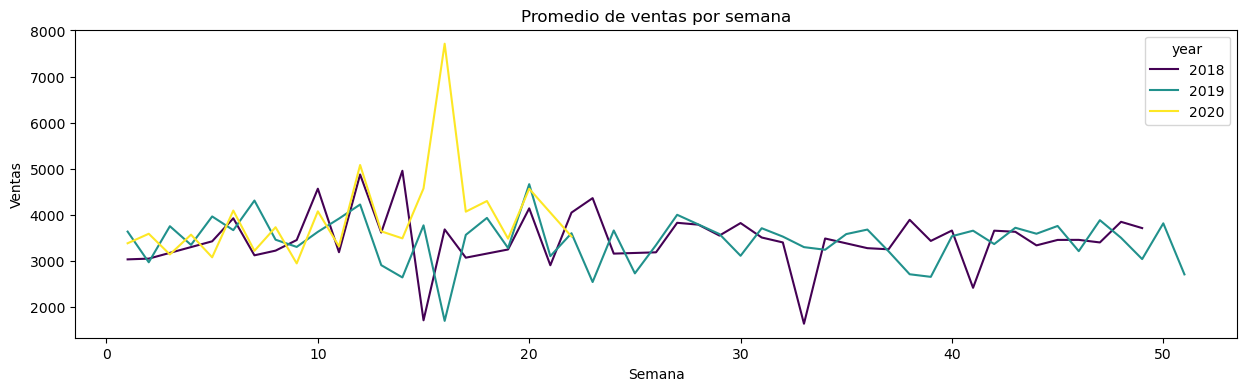

In [65]:
# Vemos el gráfico de las ventas en función de la semana para ver si hay alguna tendencia en las ventas a lo largo de los años.
plt.figure(figsize=(15, 4))
sns.lineplot(data=df, x="week", y="sales", palette="viridis", ci=None, estimator='mean', hue="year")
plt.title("Promedio de ventas por semana")
plt.xlabel("Semana")
plt.ylabel("Ventas")
plt.show()

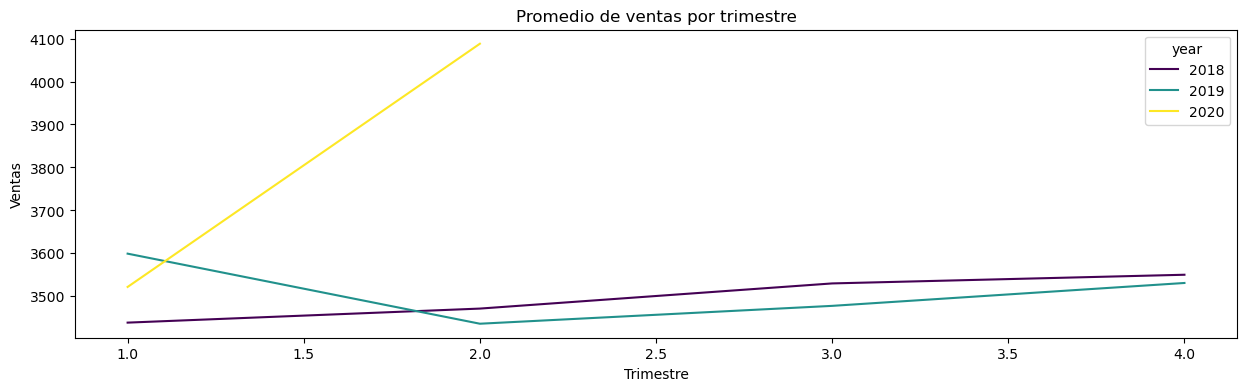

In [66]:
# Vemos el gráfico de las ventas en función del trimestre para ver si hay alguna tendencia en las ventas a lo largo de los años.
plt.figure(figsize=(15, 4))
sns.lineplot(data=df, x="quarter", y="sales", palette="viridis", hue="year", ci=None, estimator='mean')
plt.title("Promedio de ventas por trimestre")
plt.xlabel("Trimestre")
plt.ylabel("Ventas")
plt.show()

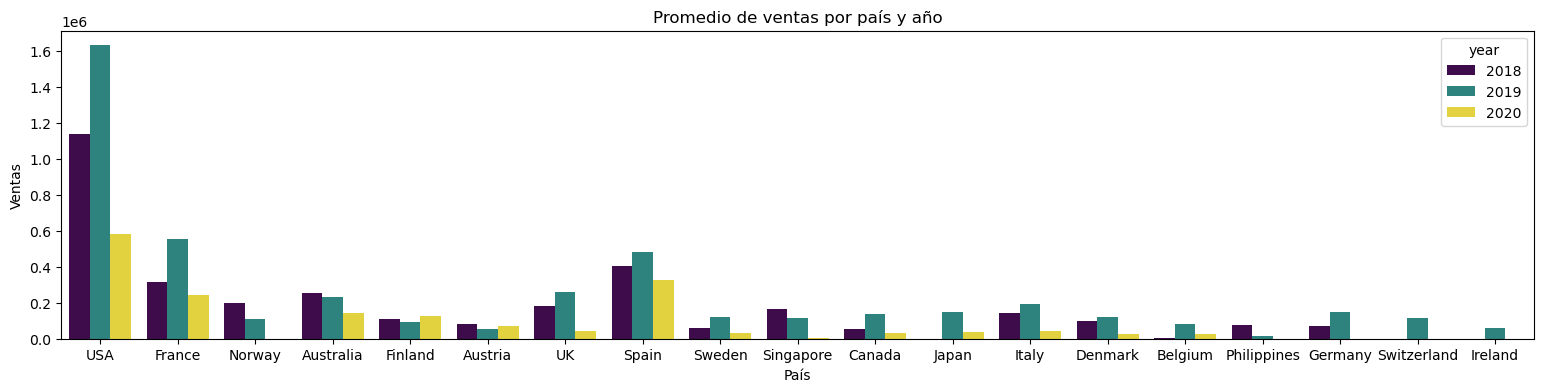

In [67]:
# Vemos las ventas en función del país y año mediante gráfico de barras.
plt.figure(figsize=(19, 4))
sns.barplot(data=df, x="country", y="sales", hue="year", palette="viridis", ci=None, estimator='sum')
plt.title("Promedio de ventas por país y año")
plt.xlabel("País")
plt.ylabel("Ventas")
plt.show()

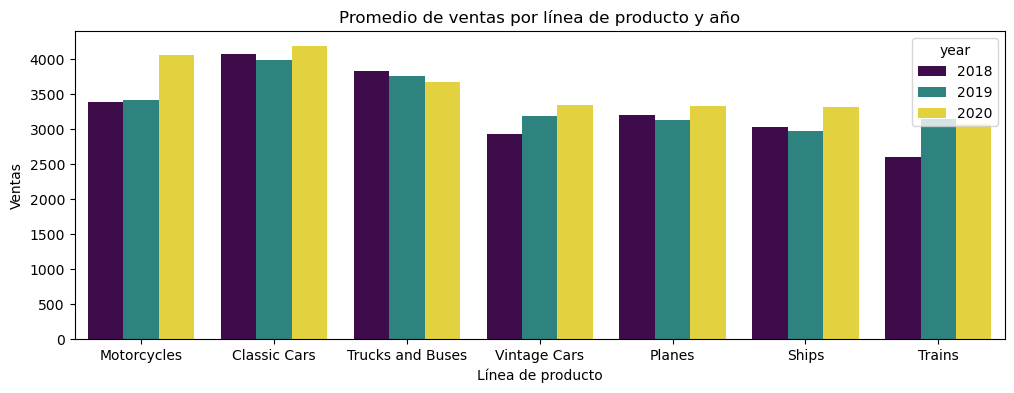

In [68]:
# Vemos las ventas por línea de producto y año mediante gráfico de barras.
plt.figure(figsize=(12, 4))
sns.barplot(data=df, x="product_line", y="sales", hue="year", palette="viridis", ci=None, estimator='mean')
plt.title("Promedio de ventas por línea de producto y año")
plt.xlabel("Línea de producto")
plt.ylabel("Ventas")
plt.show()

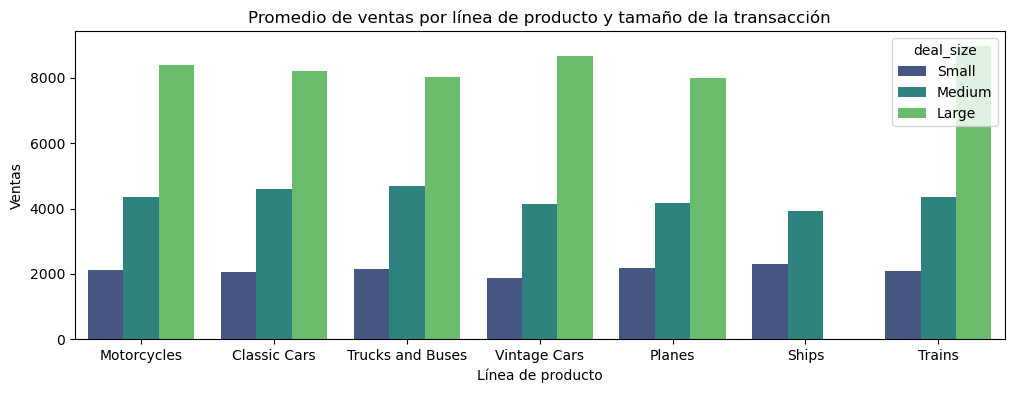

In [69]:
# Vemos las ventas por línea de producto y tamaño de la transacción mediante gráfico de barras.
plt.figure(figsize=(12, 4))
sns.barplot(data=df, x="product_line", y="sales", hue="deal_size", palette="viridis", ci=None, estimator='mean')
plt.title("Promedio de ventas por línea de producto y tamaño de la transacción")
plt.xlabel("Línea de producto")
plt.ylabel("Ventas")
plt.show()

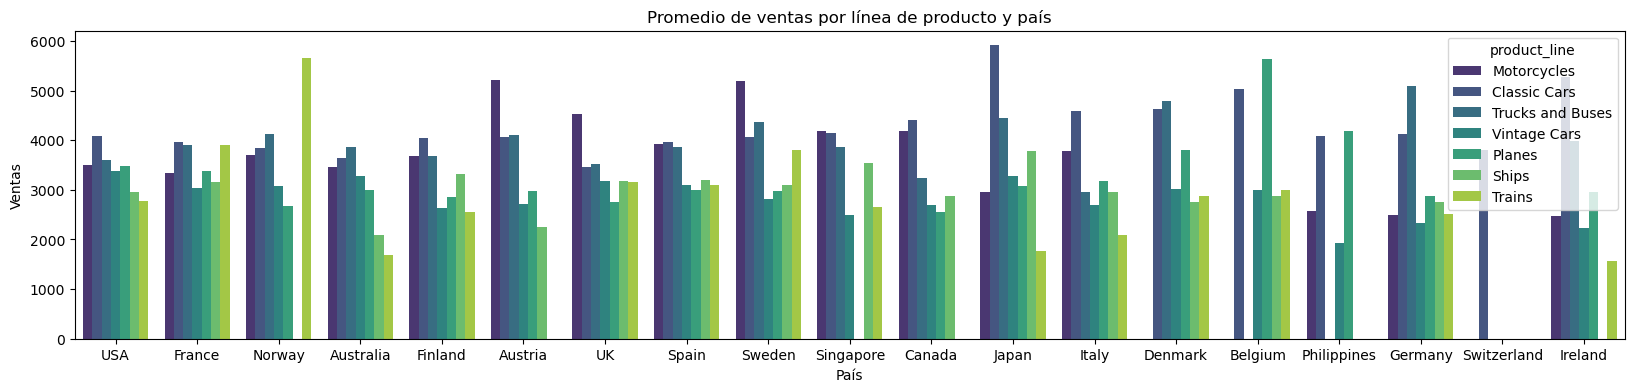

In [70]:
# Vemos las ventas por línea de producto y país mediante gráfico de barras.
plt.figure(figsize=(20, 4))
sns.barplot(data=df, x="country", y="sales", hue="product_line", palette="viridis", ci=None, estimator='mean')
plt.title("Promedio de ventas por línea de producto y país")
plt.xlabel("País")
plt.ylabel("Ventas")
plt.show()

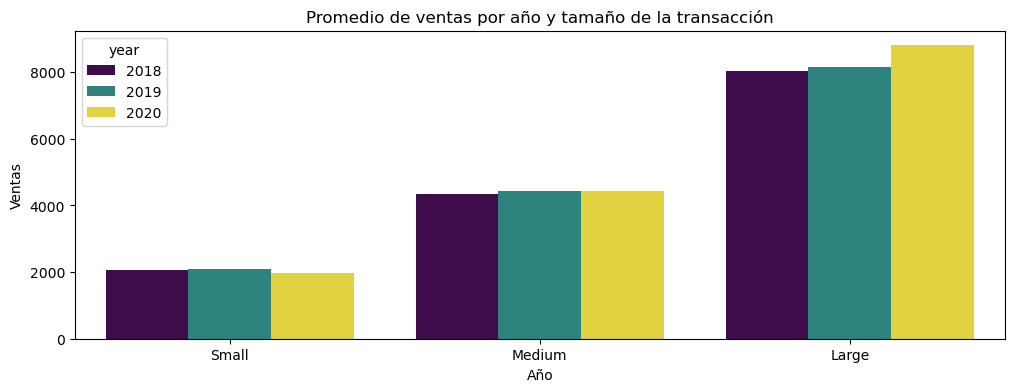

In [71]:
# # Vemos las ventas por año y tamaño de la transacción mediante gráfico de barras.
plt.figure(figsize=(12, 4))
sns.barplot(data=df, x="deal_size", y="sales", hue="year", palette="viridis", ci=None, estimator='mean')
plt.title("Promedio de ventas por año y tamaño de la transacción")
plt.xlabel("Año")
plt.ylabel("Ventas")
plt.show()

**Principales insights**

- Ventas
    - 298 pedidos únicos a 89 clientes diferentes, en 19 países y 71 ciudades.
    - El 50% de las ventas está comprendido entre 2200€ y 4500€, representando una baja varianza (poca dispersión).
    - EE.UU. lidera los países que más compras realizan, con un total de 928 pedidos (33%), seguido por España.
    - En cuanto a las ciudades, Madrid lidera con 304 transacciones, seguida de San Rafael. 
    - Existe un aumento significativo de las ventas en EE.UU y Francia en 2019.
- Producto
    - La empresa fabrica 109 artículos diferentes en 7 líneas de producto que oscila ente los 26€ y los 252€, siendo la de coches clásicos la que más ingresos genera (~35% del total), con una media de 4000€ por transacción.
    - Cerca del 70% de los ingresos vienen exclusivamente de la venta de productos para coches y motocicletas.
    - Trayectoria ascendente de las ventas de la línea de producto de coches vintage, superando siempre al año anterior. Caso opuesto al de Trucks y buses, cuyas ventas descendieron cada año.
- Transacciones
    - Casi el 95% del total de las transacciones corresponden a aquellas con tamaño pequeño o mediano, donde el 50% contienen entre 25 y 45 artículos aproximadamente.
    - Aquellas transacciones consideradas de gran tamaño han aumentado significativamente en 2020 respecto a años anteriores. 
- Tendencias temporales
    - En Julio aparece un patrón en el que hay una subida de las ventas (tanto en 2017 como en 2018).
    - Los primeros meses de 2022 superan, en cuanto a ventas, con gran diferencia los inicios tanto de 2018 como de 2019.
- Días desde la última compra
    - Podemos destacar dos grupos, aquellos que su última compra fua hace menos de 2500 días, y aquellos que han tardado más de 2500 (no sé si esto es un insight, en el histograma se ven dos montañas).
- Adquisición de nuevos clientes
    - Desde septiembre de 2019 no se han agregado nuevos clientes.
    - En 2018 hubo un total de 66 nuevos clientes adquiridos. Desde entonces ha habido una notable bajada, ya que en 2019 hubo un total de 23 nuevos clientes adquiridos, y en 2020 no hubo.
    - El periodo con mayor número de nuevos clientes adquiridos fue noviembre de 2018 (14). 



## Análisis de la adquisición de nuevos clientes

In [98]:
# Vemos el número de clientes nuevos por año.
df.groupby("customer_name")["year"].min().value_counts()

year
2018    66
2019    23
Name: count, dtype: int64

In [73]:
# Vamoa a ver el número de clientes nuevos por periodo de adquisición.
# Creamos una copia del df.
df_copia = df.copy()

In [74]:
# Vemos el año en el que cada cliente hizo su primera compra. Aplicamos transform para que nos devuelva el mismo número de 
# filas que el df original y así poder comparar con otras columnas. Además convertimos la fecha a periodo para agrupar por mes y año.
df_copia["periodo_adquisicion"] = df_copia.groupby("customer_name")["order_date"].transform("min").dt.to_period("M")
df_copia[["customer_name", "order_date", "periodo_adquisicion"]].head(10)

,customer_name,order_date,periodo_adquisicion
0,Land of Toys Inc.,2018-02-24,2018-02
1,Reims Collectables,2018-05-07,2018-05
2,Lyon Souveniers,2018-07-01,2018-07
3,Toys4GrownUps.com,2018-08-25,2018-08
4,Technics Stores Inc.,2018-10-28,2018-07
5,Daedalus Designs Imports,2018-11-11,2018-11
6,Herkku Gifts,2018-11-18,2018-11
7,Auto Canal Petit,2019-01-15,2019-01
8,"Australian Collectors, Co.",2019-02-20,2018-04
9,Vitachrome Inc.,2019-04-05,2018-01


In [75]:
# Vemos que hay duplicados, ya que aparece el mismo cliente con el mismo periodo de adquisición varias veces, ya que el tamaño del df es 
# igual de grande que el original, pero los clientes son menos. Debemos eliminarlos.
df_copia.duplicated(subset=["customer_name", "periodo_adquisicion"]).sum()

np.int64(2658)

In [76]:
# Eliminamos los duplicados para quedarnos con un df con un cliente por fila y su periodo de adquisición.
df_copia = df_copia.drop_duplicates(subset=["customer_name", "periodo_adquisicion"])

In [77]:
# Volvemos a agrupar para contar el número de clientes nuevos por periodo de adquisición.
df_num_clientes_nuevos = df_copia.groupby("periodo_adquisicion")["customer_name"].size().reset_index(name="num_clientes_nuevos").sort_values("periodo_adquisicion")

In [78]:
# Convertimos el periodo de adquisición a datetime para poder graficar la evolución del número de clientes nuevos a lo largo del tiempo.
df_num_clientes_nuevos["periodo_adquisicion"] = df_num_clientes_nuevos["periodo_adquisicion"].dt.to_timestamp()

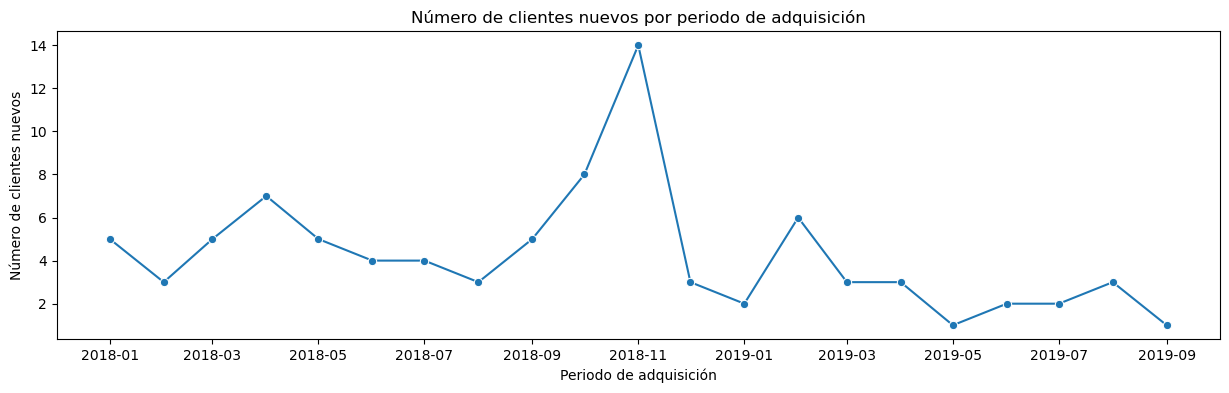

In [79]:
# Realizamos un gráfico de líneas para ver la evolución del número de clientes nuevos a lo largo del tiempo.
plt.figure(figsize=(15, 4))
sns.lineplot(data=df_num_clientes_nuevos, x="periodo_adquisicion", y="num_clientes_nuevos", palette="viridis", ci=None, marker="o")
plt.title("Número de clientes nuevos por periodo de adquisición")
plt.xlabel("Periodo de adquisición")
plt.ylabel("Número de clientes nuevos")
plt.show()

- Desde septiembre de 2019 no se han agregado nuevos clientes.
- En 2018 hubo un total de 66 nuevos clientes adquiridos. Desde entonces ha habido una notable bajada, ya que en 2019 hubo un total de 23 nuevos clientes adquiridos, y en 2020 no hubo.
- El periodo con mayor número de nuevos clientes adquiridos fue noviembre de 2018 (14).

## Análisis RFM

In [80]:
# Calculamos el RFM para cada cliente. Para ello, agrupamos por cliente y calculamos la recencia, frecuencia y monetario. Podemos hacerlo así ya que 
# ya tenemos en el df los días desde la última compra, el número de compras y el total de ventas por cliente.
df_rfm = df.groupby("customer_name").agg({
    "days_since_last_order": "min",
    "order_date": "nunique",
    "sales": "sum"
}).reset_index()

In [81]:
# Renombramos las columnas para que tengan un nombre más descriptivo.
df_rfm.rename(columns={
    "days_since_last_order": "recencia",
    "order_date": "frecuencia",
    "sales": "monetario"
}, inplace=True)

In [82]:
# Creamos los cuartiles para cada una de las variables RFM para poder segmentar a los clientes en función de su recencia, frecuencia y monetario.
df_rfm["recencia_bin"] = pd.qcut(df_rfm["recencia"].rank(method="first"), q=3, labels=[3, 2, 1])
df_rfm["frecuencia_bin"] = pd.qcut(df_rfm["frecuencia"].rank(method="first"), q=3, labels=[1, 2, 3])
df_rfm["monetario_bin"] = pd.qcut(df_rfm["monetario"].rank(method="first"), q=3, labels=[1, 2, 3])

In [83]:
# Creamos una nueva columna "total" que sume los valores de las columnas "recencia_bin", "frecuencia_bin" y "monetario_bin" para poder segmentar a 
# los clientes en función de su recencia, frecuencia y monetario.
df_rfm["total"] = df_rfm[["recencia_bin", "frecuencia_bin", "monetario_bin"]].sum(axis=1)

In [84]:
# Creamos un diccionario para asignar un tipo de cliente en función del valor de la columna "total". Asignamos "Cliente valor bajo" a los clientes 
# con un total de 3 o 4, "Cliente valor medio" a los clientes con un total de 5 o 6, "Cliente valor alto" a los clientes con un total de 
# 7 u 8 y "Cliente valor muy alto" a los clientes con un total de 9.
dicc_tipo_cliente = {
    3: "Cliente valor bajo",
    4: "Cliente valor bajo",
    5: "Cliente valor medio",
    6: "Cliente valor medio",
    7: "Cliente valor alto",
    8: "Cliente valor alto",
    9: "Cliente valor muy alto"
}

In [85]:
# Asignamos el tipo de cliente a cada cliente en función del valor de la columna "total" utilizando el diccionario creado anteriormente.
df_rfm["tipo_cliente"] = df_rfm["total"].map(dicc_tipo_cliente)

In [86]:
# Vemos el top 10 de mejores clientes en función del total, y posteriormente por su monetario, frecuencia y recencia.
df_rfm.sort_values(["total","monetario","frecuencia","recencia"], ascending=[False, False, False, True]).head(10)

,customer_name,recencia,frecuencia,monetario,recencia_bin,frecuencia_bin,monetario_bin,total,tipo_cliente
32,Euro Shopping Channel,2140,25,912294.11,3,3,3,9,Cliente valor muy alto
53,Mini Gifts Distributors Ltd.,2142,17,654858.06,3,3,3,9,Cliente valor muy alto
43,La Rochelle Gifts,2140,4,180124.90,3,3,3,9,Cliente valor muy alto
30,"Dragon Souveniers, Ltd.",2230,5,172989.68,3,3,3,9,Cliente valor muy alto
78,The Sharp Gifts Warehouse,2179,4,160010.27,3,3,3,9,Cliente valor muy alto
3,"Anna's Decorations, Ltd",2223,4,153996.13,3,3,3,9,Cliente valor muy alto
72,Souveniers And Things Co.,2142,4,151570.98,3,3,3,9,Cliente valor muy alto
67,Salzburg Collectables,2154,4,149798.63,3,3,3,9,Cliente valor muy alto
26,Danish Wholesale Imports,2186,5,145041.60,3,3,3,9,Cliente valor muy alto
63,Reims Collectables,2202,5,135042.94,3,3,3,9,Cliente valor muy alto


In [87]:
# Vemos el número de clientes por tipo de cliente.
df_tipo_cliente = df_rfm.groupby("tipo_cliente").size().reset_index(name="num_clientes").sort_values("num_clientes", ascending=False)
df_tipo_cliente

,tipo_cliente,num_clientes
1,Cliente valor bajo,26
2,Cliente valor medio,26
0,Cliente valor alto,21
3,Cliente valor muy alto,16


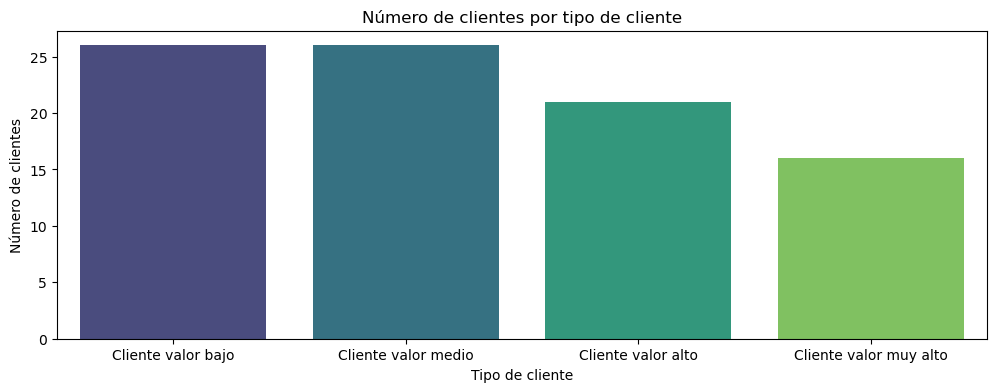

,tipo_cliente,count,percent,cumulative_count,cumulative_percent
0,Cliente valor medio,26,29.213483,26,29.213483
1,Cliente valor bajo,26,29.213483,52,58.426966
2,Cliente valor alto,21,23.595506,73,82.022472
3,Cliente valor muy alto,16,17.977528,89,100.000000


In [88]:
# graficamos el número de clientes por tipo de cliente utilizando un gráfico de barras con seaborn.
plt.figure(figsize=(12, 4)) 
sns.barplot(data=df_tipo_cliente, x="tipo_cliente", y="num_clientes", palette="viridis")
plt.title("Número de clientes por tipo de cliente")
plt.xlabel("Tipo de cliente")
plt.ylabel("Número de clientes")
plt.show()
df_rfm.stb.freq(["tipo_cliente"])

- En cuanto a recencia, frecuencia y gasto monetario los mejores clientes son Euro Shopping Channel, Diecast Classics Inc. y La Rochelle Gifts.

- Hay un total de 26 clientes de valor bajo, 26 de valor medio, 21 de valor alto y 16 de valor muy alto.

- El 42% de los clientes pertenecen al grupo de clientes de valor alto o muy alto. 

## ANOVA

Realizamos un ANOVA con la VD "sales" y la VI "product_line" para ver si hay diferencias significativas en las ventas entre las diferentes líneas de producto.

In [90]:
# Paso 1: Creamos los grupos de ventas por línea de producto.
grupo_motorcycles = df[df["product_line"] == "Motorcycles"]["sales"]
grupo_classiccars = df[df["product_line"] == "Classic Cars"]["sales"]
grupo_trucksbuses = df[df["product_line"] == "Trucks and Buses"]["sales"]
grupo_vintagecars = df[df["product_line"] == "Vintage Cars"]["sales"]
grupo_planes = df[df["product_line"] == "Planes"]["sales"]
grupo_ships = df[df["product_line"] == "Ships"]["sales"]
grupo_trains = df[df["product_line"] == "Trains"]["sales"]

Realizamos el análisis de Shapiro_Wilk para comprobar el supuesto de normalidad.

- H₀: los datos siguen distribución normal.
- H₁: los datos no son normales.

In [91]:
# Paso 2: Comprobamos el supuesto de normalidad para cada grupo utilizando el test de Shapiro-Wilk.
print("Test de Shapiro-Wilk para el grupo 'Motorcycles':")
print(stats.shapiro(grupo_motorcycles))
print("\nTest de Shapiro-Wilk para el grupo 'Classic Cars':")
print(stats.shapiro(grupo_classiccars))
print("\nTest de Shapiro-Wilk para el grupo 'Trucks and Buses':")
print(stats.shapiro(grupo_trucksbuses))
print("\nTest de Shapiro-Wilk para el grupo 'Vintage Cars':")
print(stats.shapiro(grupo_vintagecars))
print("\nTest de Shapiro-Wilk para el grupo 'Planes':")
print(stats.shapiro(grupo_planes))
print("\nTest de Shapiro-Wilk para el grupo 'Ships':")
print(stats.shapiro(grupo_ships))
print("\nTest de Shapiro-Wilk para el grupo 'Trains':")
print(stats.shapiro(grupo_trains))

Test de Shapiro-Wilk para el grupo 'Motorcycles':
ShapiroResult(statistic=np.float64(0.912715550738024), pvalue=np.float64(1.6581152237761492e-12))

Test de Shapiro-Wilk para el grupo 'Classic Cars':
ShapiroResult(statistic=np.float64(0.9543170171270013), pvalue=np.float64(1.3381709544235016e-16))

Test de Shapiro-Wilk para el grupo 'Trucks and Buses':
ShapiroResult(statistic=np.float64(0.9680397290373923), pvalue=np.float64(4.017836266940722e-06))

Test de Shapiro-Wilk para el grupo 'Vintage Cars':
ShapiroResult(statistic=np.float64(0.8859351538101997), pvalue=np.float64(2.972213217492487e-20))

Test de Shapiro-Wilk para el grupo 'Planes':
ShapiroResult(statistic=np.float64(0.8946955816566641), pvalue=np.float64(1.1175690876112072e-13))

Test de Shapiro-Wilk para el grupo 'Ships':
ShapiroResult(statistic=np.float64(0.9503524197062709), pvalue=np.float64(4.2727060123383324e-07))

Test de Shapiro-Wilk para el grupo 'Trains':
ShapiroResult(statistic=np.float64(0.8676100127480925), pvalue

El resultado muestra que los datos no siguen una distribución normal. Comprobamos n de cada grupo, si es una mustra grande, podemos realizar un ANOVA clásico, ya que es robusto para grupos que no suguen una distribución normal.



In [92]:
# Comprobamos n de cada grupo para ver si el tamaño de la muestra es suficiente para aplicar el test de ANOVA.
print("Número de muestras en el grupo 'Motorcycles':", len(grupo_motorcycles))
print("Número de muestras en el grupo 'Classic Cars':", len(grupo_classiccars))
print("Número de muestras en el grupo 'Trucks and Buses':", len(grupo_trucksbuses))
print("Número de muestras en el grupo 'Vintage Cars':", len(grupo_vintagecars))
print("Número de muestras en el grupo 'Planes':", len(grupo_planes))
print("Número de muestras en el grupo 'Ships':", len(grupo_ships))
print("Número de muestras en el grupo 'Trains':", len(grupo_trains))

Número de muestras en el grupo 'Motorcycles': 313
Número de muestras en el grupo 'Classic Cars': 949
Número de muestras en el grupo 'Trucks and Buses': 295
Número de muestras en el grupo 'Vintage Cars': 579
Número de muestras en el grupo 'Planes': 304
Número de muestras en el grupo 'Ships': 230
Número de muestras en el grupo 'Trains': 77


Los grupos son lo suficientemente grandes como para poder seguir realizando el ANOVA. Comprobamos el supuesto de homocedasticidad.

- H₀: varianzas iguales entre grupos.
- H₁: varianzas diferentes.


In [93]:
# Paso 3: Comprobamos el supuesto de homogeneidad de varianzas utilizando el test de Levene.
print("Test de Levene para comprobar la homogeneidad de varianzas entre los grupos:")
print(stats.levene(grupo_motorcycles, grupo_classiccars, grupo_trucksbuses, grupo_vintagecars, grupo_planes, grupo_ships, grupo_trains))

Test de Levene para comprobar la homogeneidad de varianzas entre los grupos:
LeveneResult(statistic=np.float64(19.43166177324013), pvalue=np.float64(2.6092309332702825e-22))


Tras realizar el test de Levene rechazamos la H₀. Podemos ver como las varianzas entre los grupos es diferente, por lo que debemos realizar Welch ANOVA.

- H₀: todas las medias son iguales.
- H₁: al menos una media difiere.


In [94]:
# Realizamos el ANOVA WELCH para comparar las medias de las ventas entre las diferentes líneas de producto, ya que el test de Levene ha indicado que no se cumple el supuesto de homogeneidad de varianzas.
anova_welch = pg.welch_anova(dv="sales", between="product_line", data=df)
print("Resultados del ANOVA WELCH:") 
print(anova_welch)

Resultados del ANOVA WELCH:
         Source  ddof1       ddof2          F         p_unc       np2
0  product_line      6  652.718899  27.209833  5.035930e-29  0.052253


- Tras la realización del ANOVA de Welch, rechazamos la H₀, por lo que existen diferencias estadísticamente significativas en las ventas entre, al menos, dos de las líneas de producto. Además el eta cuadrado es de 0.052, lo que significa que la línea de producto explica aproximadamente el 5.2% de la varianza total de las ventas. El efecto es pequeño-moderado.

- Una vez visto que sí que existen diferencias significativas, vemos en qué lineas de producto aparecen las diferencias para determinar cuáles son mejores. Para ello realizamos análisis Post-Hoc mediante el test de Games-Howell.


In [95]:
# Realizamos post-hoc con el test de Games-Howell para ver qué grupos son los que presentan diferencias significativas entre ellos.
post_hoc = pg.pairwise_gameshowell(dv="sales", between="product_line", data=df)
print("Resultados del test de Games-Howell:")
print(post_hoc)

Resultados del test de Games-Howell:
                   A                 B       mean_A       mean_B         diff  \
0       Classic Cars       Motorcycles  4049.387292  3525.598051   523.789241   
1       Classic Cars            Planes  4049.387292  3188.563882   860.823410   
2       Classic Cars             Ships  4049.387292  3043.648783  1005.738509   
3       Classic Cars            Trains  4049.387292  2938.226883  1111.160409   
4       Classic Cars  Trucks and Buses  4049.387292  3767.997254   281.390038   
5       Classic Cars      Vintage Cars  4049.387292  3120.337962   929.049330   
6        Motorcycles            Planes  3525.598051  3188.563882   337.034170   
7        Motorcycles             Ships  3525.598051  3043.648783   481.949269   
8        Motorcycles            Trains  3525.598051  2938.226883   587.371168   
9        Motorcycles  Trucks and Buses  3525.598051  3767.997254  -242.399203   
10       Motorcycles      Vintage Cars  3525.598051  3120.337962   405.2

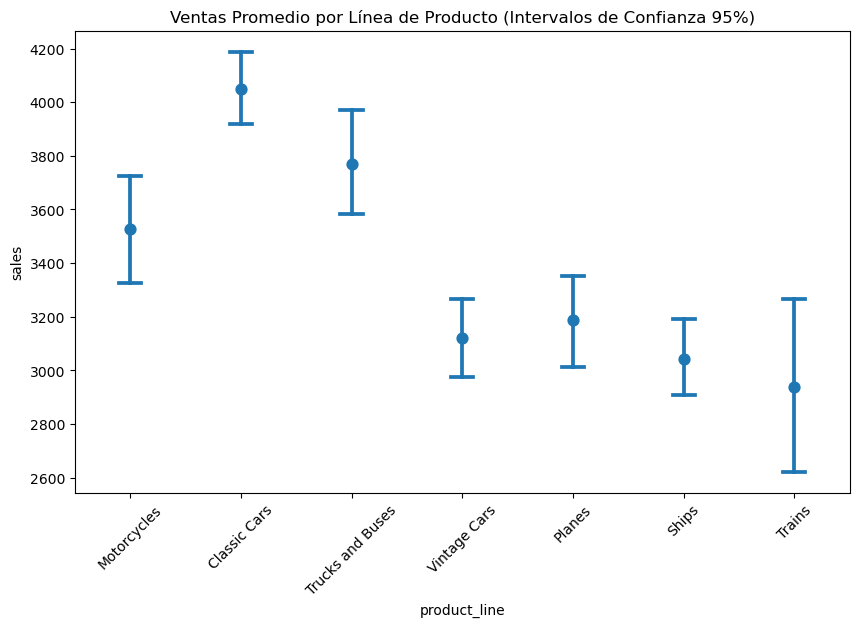

In [96]:
# Para visualizar las diferencias entre las líneas de producto, podemos hacer un gráfico de puntos para ver el promedio de ventas por línea de 
# producto y los intervalos de confianza del 95%.
plt.figure(figsize=(10, 6))
sns.pointplot(data=df, x='product_line', y='sales', join=False, capsize=.2)
plt.title('Ventas Promedio por Línea de Producto (Intervalos de Confianza 95%)')
plt.xticks(rotation=45)
plt.show()

**Conclusiones del ANOVA**
- Liderazgo de Classic Cars y Trucks & Buses: Se confirma que las líneas de Classic Cars y Trucks and Buses son los motores de ventas de la compañía, sin que existan diferencias estadísticas significativas entre ambas ($p > 0.05$). Classic Cars destaca especialmente al superar de forma robusta a casi todas las demás categorías, con una diferencia de media superior a 1000€ frente a los segmentos de menor rendimiento como Ships o Trains.

- Segmentación del Rendimiento Medio y Bajo: Existe un escalón intermedio ocupado por Motorcycles, que mantiene una posición competitiva superior a las líneas de menor volumen, pero significativamente por debajo del segmento líder. Por otro lado, las categorías de Planes, Ships, Vintage Cars y Trains no presentan diferencias significativas entre sí ($p \approx 0.99$ en varios cruces), comportándose como un bloque homogéneo de bajo rendimiento relativo.

- Magnitud del Impacto (Tamaño del Efecto): El análisis del estadístico Hedges' g revela efectos moderados (cercanos a $0.50$) en las comparaciones de los líderes frente a las líneas bajas, lo que indica que las diferencias halladas no son solo fruto del azar por el gran tamaño de la muestra, sino que tienen una relevancia práctica importante para la estrategia comercial y la asignación de recursos de la empresa.